# Exploratory Data Analysis Assignment


The goals of the exploratory data analysis are:
*   to better understand your data,
*   to evaluate if the given dataset is suitable for the K-Means clustering task.

&nbsp;

You need to:

**Step 1:** Load the given Banknote authentication dataset.

**Step 2:** Calculate statistical measures, e.g. mean and standard deviation.

**Step 3:** Visualise your data as you consider fit.

**Step 4:** Evaluate if the given dataset is suitable for the K-Means clustering task.

**Step 5:** Write a short description of the dataset and your evaluation of its suitability for the K-Means clustering task.

&nbsp;

This description and evaluation must have the following characteristics:
*   the description is informative and relies on statistical measures.
*   the evaluation of the suitability is based on the characteristics of the dataset.  

## Loading the nedeed libraries, modules and packages

In [2]:
import pandas as pd                                  # Data manipulation and analysis (DataFrames, tables)
import numpy as np                                   # Numerical operations (arrays, math functions)
import matplotlib.pyplot as plt                      # Plotting module for creating visualizations (plots, charts)
import seaborn as sns                                # Advanced statistical visualizations (built on top of Matplotlib)
from sklearn.cluster import KMeans                   # Clustering algorithm from scikit-learn for unsupervised learning

/home/rw/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Loading the Note Bank Authentication file

In [3]:
# Reads a CSV file and loads it into a pandas DataFrame
data = pd.read_csv("/home/rw/Área de Trabalho/Data Science/IBM Data Science Foundations Specialization/1. A Data Clustering Project/BankNoteAuthentication.csv")

# Displays the first 5 rows of the DataFrame 'data'
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Information about the structure of the data set

In [4]:
data.info()                                          # Displays a concise summary of the DataFrame 'data'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
data.isnull().sum()                                  # Counts the number of missing (NaN) values in each column

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

## Statistical measures computation

In [6]:
data_max = data.max(0)                               # Computes the maximum value for each column in the DataFrame
print(data_max)

variance     6.8248
skewness    12.9516
curtosis    17.9274
entropy      2.4495
class        1.0000
dtype: float64


In [7]:
data_min = data.min(0)                               # Computes the minimum value for each column in the DataFrame 
print(data_min)

variance    -7.0421
skewness   -13.7731
curtosis    -5.2861
entropy     -8.5482
class        0.0000
dtype: float64


In [8]:
data_mean = data.mean(0)                             # Computes the mean (average) of each column in the DataFrame
print(data_mean)

variance    0.433735
skewness    1.922353
curtosis    1.397627
entropy    -1.191657
class       0.444606
dtype: float64


In [9]:
data_median = data.median(0)                         # Computes the median of each column
print(data_median)

variance    0.49618
skewness    2.31965
curtosis    0.61663
entropy    -0.58665
class       0.00000
dtype: float64


In [10]:
data_std = data.std(0)                               # Calculate the standard deviation of each column
print(data_std)

variance    2.842763
skewness    5.869047
curtosis    4.310030
entropy     2.101013
class       0.497103
dtype: float64


###  Resume of the statistical measures in a single table




In [11]:
# Creates a dictionary that stores summary statistics for each attribute
stat_info_data = {"attribute": ["variance", "skewness", "curtosis", "entropy", "class"], "max": data.max(0).values, "min": data.min(0).values,
                  "mean": data.mean(0).values, "median": data.median(0).values, "std": data.std(0).values}


# Convert the dictionary 'stat_info_data' into a pandas DataFrame
stat_info_res = pd.DataFrame(stat_info_data)
stat_info_res

,attribute,max,min,mean,median,std
0,variance,6.8248,-7.0421,0.433735,0.49618,2.842763
1,skewness,12.9516,-13.7731,1.922353,2.31965,5.869047
2,curtosis,17.9274,-5.2861,1.397627,0.61663,4.310030
3,entropy,2.4495,-8.5482,-1.191657,-0.58665,2.101013
4,class,1.0000,0.0000,0.444606,0.00000,0.497103


## Data standardisation

In [12]:
# # Create a separate copy of 'data'
data_norm = data.copy()                           

columns = ["variance", "skewness", "curtosis", "entropy"]

# Apply z-score normalization
for i, col in enumerate(columns):
  data_norm[col] = (data_norm[col] - stat_info_res.loc[i, "mean"])/stat_info_res.loc[i, "std"]

data_norm

,variance,skewness,curtosis,entropy,class
0,1.121397,1.149036,-0.975614,0.354432,0
1,1.446538,1.064065,-0.894710,-0.128721,0
2,1.207369,-0.777069,0.122174,0.617848,0
3,1.063355,1.295005,-1.254940,-1.143612,0
4,-0.036758,-1.086642,0.736462,0.096552,0
...,...,...,...,...,...
1367,-0.009707,-0.097657,-0.660721,0.300887,1
1368,-0.641079,-1.158562,1.178593,0.729861,1
1369,-1.471820,-2.620690,3.757647,-0.754609,1
1370,-1.406180,-1.755831,2.551113,-0.043143,1


## Some graphical visualizations

### Histograms

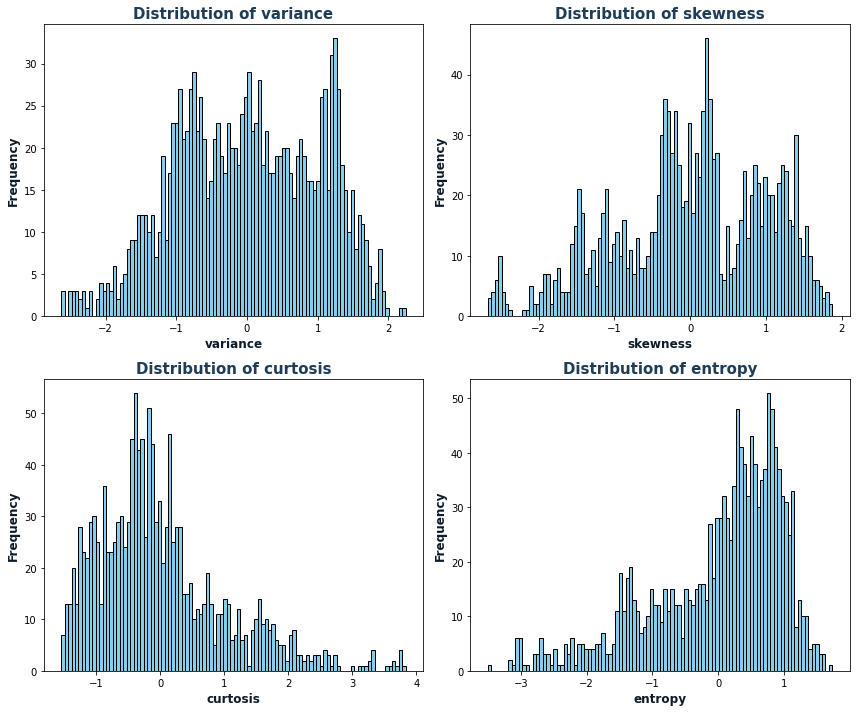

In [13]:
# Create a figure and a set of subplots (2 rows, 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# List of columns to plot
columns_to_plot = ['variance', 'skewness', 'curtosis', 'entropy']

# Plot each column in a separate subplot
for i, col in enumerate(columns_to_plot):
    axes[i].hist(data_norm[col], bins=100 , color='skyblue', edgecolor="black", histtype='bar')
    axes[i].set_title(f'Distribution of {col}', fontsize=15, color="#1E3D59", fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12, color="#0D1B2A", fontweight='heavy')
    axes[i].set_ylabel('Frequency', fontsize=12, color="#0D1B2A", fontweight='heavy')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the combined figure
plt.show()

### Scatter plots

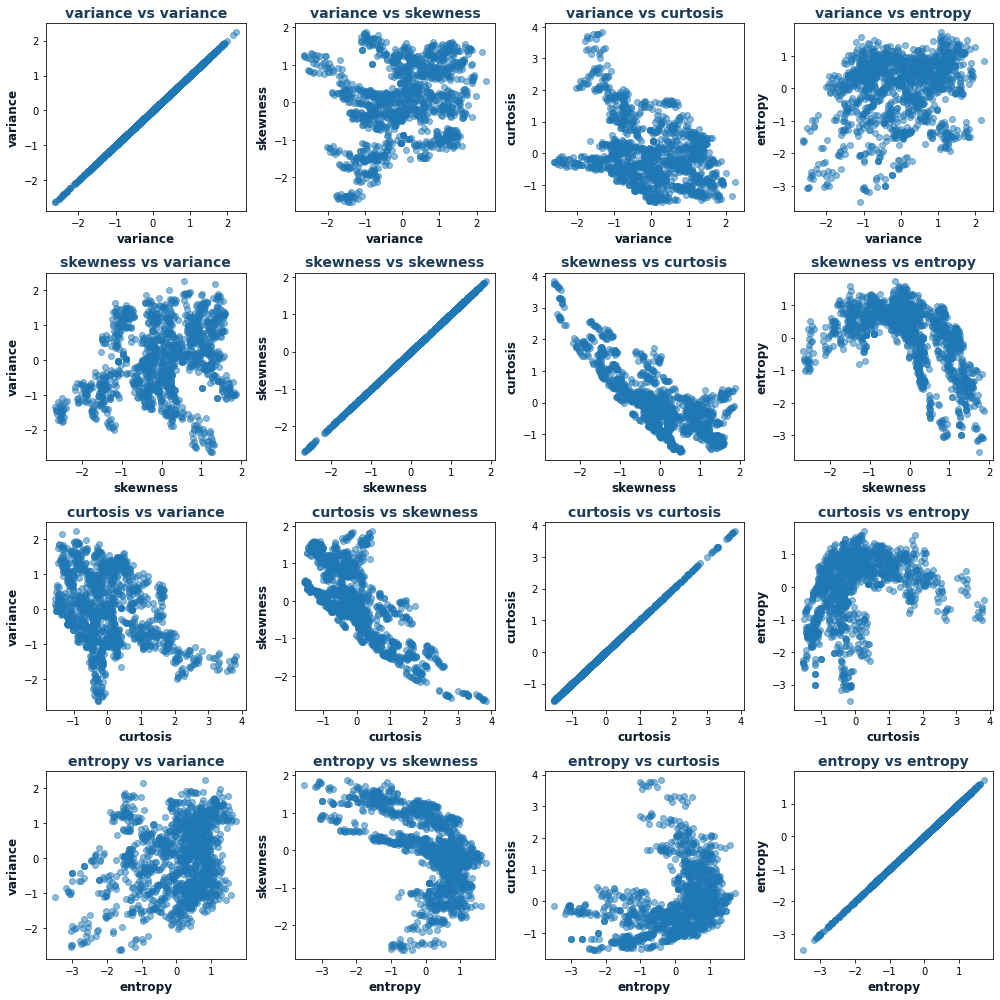

In [14]:
# Create a figure and a set of subplots (4 rows, 4 columns for 16 plots)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 14))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# List of columns to plot
columns_to_plot2 = ['variance', 'skewness', 'curtosis', 'entropy']

# Plot each column in a separate subplot
k = 0
for col1 in columns_to_plot2:
  for col2 in columns_to_plot2:
    axes[k].scatter(data_norm[col1], data_norm[col2], alpha=0.5)
    axes[k].set_title(f'{col1} vs {col2}', fontsize=14, color="#1E3D59", fontweight='bold')
    axes[k].set_xlabel(col1, fontsize=12, color="#0D1B2A", fontweight='heavy')
    axes[k].set_ylabel(col2, fontsize=12, color="#0D1B2A", fontweight='heavy')
    k += 1

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the combined figure
plt.show()

## K-Means clustering

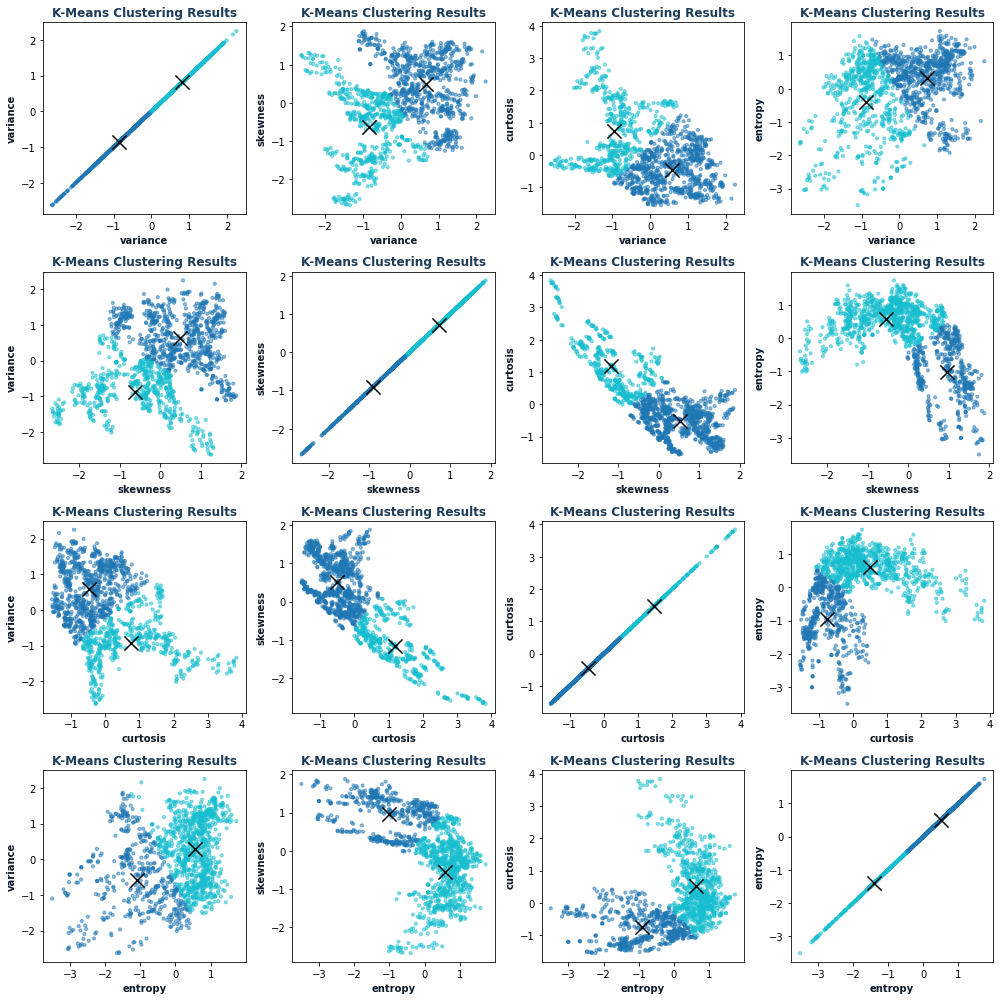

In [15]:
# Create a figure and a set of subplots (4 rows, 4 columns for 16 plots)
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(14, 14))

# Flatten the axes array for easier iteration
ax = ax.flatten()

# List of columns to plot
cols_to_plot = ['variance', 'skewness', 'curtosis', 'entropy']

n = 0
for col1 in cols_to_plot:
  for col2 in cols_to_plot:
    X = np.column_stack((data_norm[col1], data_norm[col2]))
    kmeans = KMeans(n_clusters=2).fit(X)
    y_kmeans = kmeans.predict(X)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_


    # Visualize the results
    ax[n].scatter(X[:, 0], X[:, 1],  c=y_kmeans, s=10, cmap='tab10', alpha=0.5)
    #Plot the centroids as black crosses
    ax[n].scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='x')
    ax[n].set_title("K-Means Clustering Results",  color="#1E3D59", fontweight = "bold")
    ax[n].set_xlabel(col1, color="#0D1B2A", fontweight = "bold")
    ax[n].set_ylabel(col2, color="#0D1B2A", fontweight = "bold")
    n +=1

plt.tight_layout()
plt.show()

## Results

### Data set description

The dataset contains numerical measurements extracted from banknote images.  Variance represents the level of variation in pixel values, while skewness describes the asymmetry of their distribution. These two attributes are continuous and quantitative, making them appropriate inputs for distance-based analysis. Descriptive statistics show that both variance and skewness have wide value ranges and non-zero means, indicating that the observations are meaningfully distributed. Their standard deviations are relatively large, demonstrating substantial variability across banknotes rather than uniform or repetitive measurements.


The histograms of variance and skewness reveal non-uniform and asymmetric distributions, particularly for skewness. This suggests the presence of different behavioral patterns within the data rather than random noise.

The scatter plot combining variance and skewness shows that observations are not randomly dispersed. Instead, points form visible concentrations in specific regions, indicating potential natural groupings when both attributes are considered together.

### Suitability for K-Means Clustering

Based on the descriptive statistics, the variance and skewness histograms, and the variance-skewness scatter plot, the dataset demonstrates characteristics that are well aligned with the assumptions of K-Means clustering. The data shows sufficient dispersion, structured distributions, and clear patterns that support meaningful group formation.

#### K-Means clustering for variance (V1) and skewness (V2)

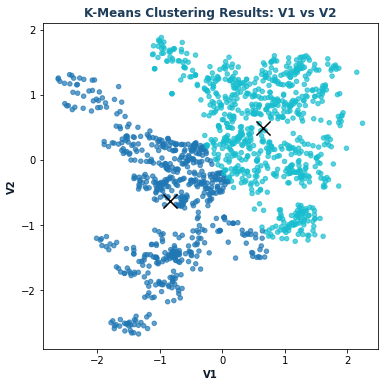

In [16]:
# Create a figure and a set of subplots (4 rows, 4 columns for 16 plots)
fig, ax2 = plt.subplots(figsize=(6, 6))


X2 = np.column_stack((data_norm["variance"], data_norm["skewness"]))
kmeans2 = KMeans(n_clusters=2).fit(X2)
y_kmeans2 = kmeans2.predict(X2)
centroids2 = kmeans2.cluster_centers_
labels2 = kmeans2.labels_


# Visualize the results
ax2.scatter(X2[:, 0], X2[:, 1],  c=y_kmeans2, s=20, cmap='tab10', alpha=0.7)
#Plot the centroids as black crosses
ax2.scatter(centroids2[:, 0], centroids2[:, 1], c='black', s=200, marker='x')
ax2.set_title("K-Means Clustering Results: V1 vs V2", color="#1E3D59", fontweight = "bold")
ax2.set_xlabel("V1", color="#0D1B2A", fontweight = "bold")
ax2.set_ylabel("V2", color="#0D1B2A", fontweight = "bold")

#plt.tight_layout()
plt.show()

### Conclusion

When considering only variance and skewness, the dataset is well-suited for K-Means clustering, provided that normalization is applied. The statistical evidence and visual that have been presented indicate that these attributes capture meaningful differences between observations, enabling effective grouping for further analysis or decision-making.